In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import calendar

In [5]:
df1=pd.read_csv(r'~\avalanche_sat\Data\dataset1.csv')
df1['Dataset']='Data1'
df2=pd.read_csv(r'~\avalanche_sat\Data\dataset2.csv')
df2['Dataset']='Data2'
df3=pd.read_csv(r'~\avalanche_sat\Data\dataset3_nowcast.csv')
df3['Dataset']='Data3_nowcast'

df=pd.concat([df1, df2,df3]).drop(columns='Unnamed: 0')
df = df.loc[:, ~df.columns.duplicated()]


df['year']=pd.to_datetime(df['datum']).dt.year
df['month'] = pd.to_datetime(df['datum']).dt.strftime('%B')



month_order = list(calendar.month_name)[1:]  # ['January', ..., 'December']

selected_months = [ 'December','January', 'February', 'March', 'April']
df=df.drop(columns=['Unnamed: 0.1.1'])
df.to_csv(r'~\avalanche_sat\Data\full_dataset.csv', index=False)

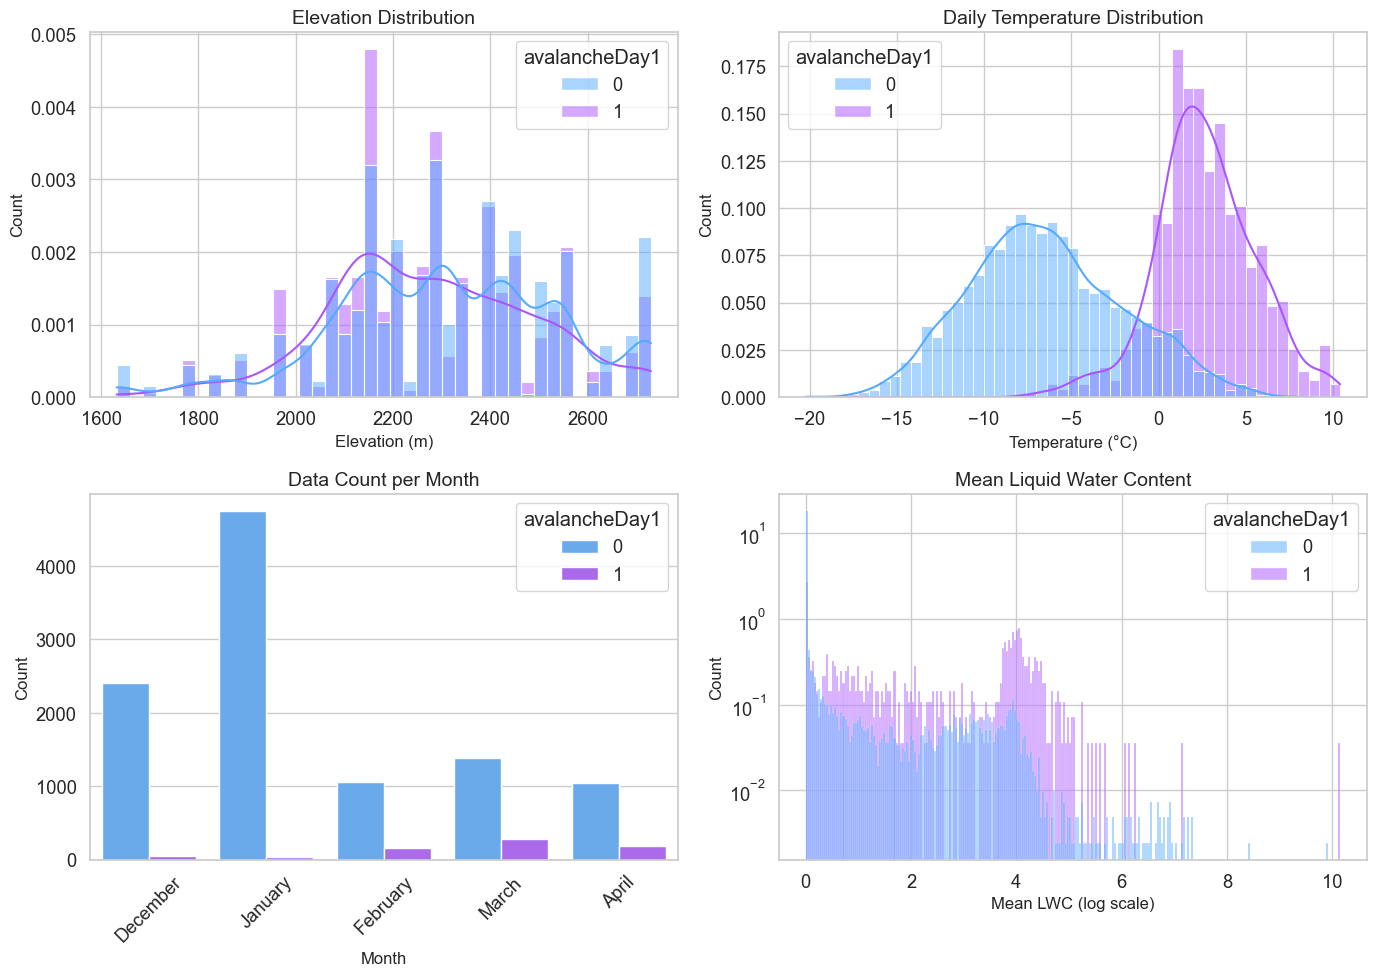

In [6]:

# Set a pretty seaborn style
sns.set(style='whitegrid', font_scale=1.2)

# Prepare month order
selected_months = ['December', 'January', 'February', 'March', 'April']

# Create subplots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
ax = ax.flat

# 1st plot: Elevation Histogram
sns.histplot(
    data=df,
    x='elevation',
    ax=ax[0],
    kde=True,
 palette='cool',

    hue='avalancheDay1',
    stat='density',   # <-- THIS normalizes it!
    common_norm=False # <-- THIS normalizes *separately* for each hue
)
ax[0].set_title('Elevation Distribution', fontsize=14)
ax[0].set_xlabel('Elevation (m)', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)

# 2nd plot: Temperature Histogram
sns.histplot(data=df, x='TA_daily', ax=ax[1], kde=True, hue='avalancheDay1',  stat='density',  common_norm=False, palette='cool')
ax[1].set_title('Daily Temperature Distribution', fontsize=14)
ax[1].set_xlabel('Temperature (°C)', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)

# 3rd plot: Month Countplot
sns.countplot(data=df, x='month', ax=ax[2], order=selected_months, palette='cool', hue='avalancheDay1')
ax[2].set_title('Data Count per Month', fontsize=14)
ax[2].set_xlabel('Month', fontsize=12)
ax[2].set_ylabel('Count', fontsize=12)
ax[2].tick_params(axis='x', rotation=45)

# 4th plot: Mean LWC Histogram
sns.histplot(
    data=df,
    x='mean_lwc',
    ax=ax[3],
 palette='cool',
    hue='avalancheDay1',
    stat='density',
    common_norm=False
)
ax[3].set_title('Mean Liquid Water Content', fontsize=14)
ax[3].set_xlabel('Mean LWC (log scale)', fontsize=12)
ax[3].set_ylabel('Count', fontsize=12)
ax[3].set_yscale('log')

# Adjust layout
plt.tight_layout()
plt.show()

